<h1 style='color:#5BC0EB; font-weight:800; font-size:1.9em; margin-bottom:0.3em'>Sistema de Decisión Adaptativa</h1>
<h3 style='color:#A8D8EA; font-weight:400; font-size:1.1em; margin-top:0'>Selección de método — Segmentación adaptativa — Ensemble — Benchmark y síntesis</h3>
<p style='color:#b0b0b0; font-size:0.9em'>Continuación de <em>Análisis de Descriptores</em>: a partir del clasificador entrenado se construye el sistema que recomienda el método óptimo para cada curva y lo aplica por segmentos.</p>

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, cross_val_score,
    learning_curve, train_test_split)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import joblib

try:
    import shap; SHAP_OK = True
except ImportError:
    SHAP_OK = False

try:
    import umap; UMAP_OK = True
except (ImportError, OSError, AttributeError):
    UMAP_OK = False

try:
    from scikit_posthocs import posthoc_dunn; DUNN_OK = True
except ImportError:
    DUNN_OK = False

print(f'SHAP: {SHAP_OK}  |  UMAP: {UMAP_OK}  |  Dunn posthoc: {DUNN_OK}')

SHAP: True  |  UMAP: True  |  Dunn posthoc: True


In [125]:
import joblib
from pathlib import Path

MODELOS_DIR = Path.cwd().parent / 'modelos'
_ckpt = joblib.load(MODELOS_DIR / 'checkpoint_descriptores.pkl')
df             = _ckpt['df']
X_clean        = _ckpt['X_clean']
y_label        = _ckpt['y_label']
feat_final     = _ckpt['feat_final']
FEATURES_PIXEL = _ckpt['FEATURES_PIXEL']
Xs             = _ckpt['Xs']
fitted         = _ckpt['fitted']
results        = _ckpt['results']
MODELS         = _ckpt['MODELS']
SKF            = _ckpt['SKF']
scores_stack   = _ckpt['scores_stack']
print('Checkpoint cargado. Curvas:', len(df))
print('Features totales:', len(feat_final), '| Features pixel:', len(FEATURES_PIXEL))

Checkpoint cargado. Curvas: 500
Features totales: 25 | Features pixel: 12


In [126]:
ROOT   = Path.cwd().parent
DATA_T = ROOT / 'datos' / 'target'
DATA_P = ROOT / 'datos' / 'pixel_curves'

def leer_target(cid):
    return pd.read_csv(DATA_T / f'curve_{cid:04d}.txt',
                       header=None, names=['x','y']).sort_values('x').reset_index(drop=True)

def leer_pixel(cid, escala):
    return pd.read_csv(DATA_P / f'curve_{cid:04d}_X{escala}.txt',
                       sep=' ', header=None, names=['x','y']).sort_values('x').reset_index(drop=True)

PALETTE = {
    'polinomio':  '#2E86AB',
    'gaussianas': '#A23B72',
    'spline':     '#F18F01',
    'neutro':     '#4A4A4A'}
METHODS = ['polinomio', 'gaussianas', 'spline']
SCALES  = [10, 15, 18, 21, 25]

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10})

def ax_style(ax, title='', xlabel='', ylabel=''):
    if title:  ax.set_title(title, pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

def method_patches():
    return [mpatches.Patch(color=PALETTE[m], label=m) for m in METHODS]

def compute_pixel_features(df_curve):
    x = df_curve['x'].values.astype(float)
    y = df_curve['y'].values.astype(float)
    n = len(x)
    if n < 5: return {}
    dy_ = np.diff(y)
    yr = float(y.max() - y.min())
    xr = float(x.max() - x.min())
    yf = np.abs(np.fft.rfft(y - y.mean()))
    fr = np.fft.rfftfreq(n); yf[0] = 0; yfmax = yf.max()
    if yfmax > 0:
        tp   = (yf**2).sum() + 1e-12
        cent = float((fr * yf**2).sum() / tp)
        pks, _ = find_peaks(yf, height=0.1*yfmax)
        nfp  = float(len(pks))
    else:
        cent = nfp = 0.0
    W  = max(5, n // 20)
    km = []
    for i in range(0, n - W, max(1, W // 2)):
        sx, sy = x[i:i+W], y[i:i+W]
        if len(sx) < 3: continue
        dy2  = np.gradient(sy, sx)
        d2y2 = np.gradient(dy2, sx)
        km.append(float(np.mean(np.abs(d2y2) / (1 + dy2**2)**1.5)))
    loc_comp = float(np.std(km)) if len(km) > 1 else 0.0
    pks_y, _ = find_peaks(y); vals_y, _ = find_peaks(-y)
    feats = {
        'y_range': yr, 'x_range': xr, 'aspect_ratio': yr / (xr + 1e-9),
        'y_skewness': float(stats.skew(y)), 'y_kurtosis': float(stats.kurtosis(y)),
        'monotonicity_score': float((dy_ > 0).sum() / max(len(dy_), 1)),
        'local_complexity': loc_comp, 'fft_spectral_centroid': cent,
        'fft_n_peaks': nfp, 'n_maxima': float(len(pks_y)), 'n_minima': float(len(vals_y))}
    slope_vals = np.diff(y) / (np.diff(x) + 1e-9)
    feats['slope_mean']    = float(np.mean(np.abs(slope_vals)))
    feats['angle_range']   = float(np.ptp(np.arctan(slope_vals)))
    feats['n_inflection']  = float(np.sum(np.diff(np.sign(np.diff(y))) != 0))
    dy2_full  = np.gradient(y, x)
    d2y2_full = np.gradient(dy2_full, x)
    curv = np.abs(d2y2_full) / (1 + dy2_full**2)**1.5
    feats['curvature_mean'] = float(np.mean(curv))
    feats['curvature_max']  = float(np.max(curv))
    feats['curvature_q95']  = float(np.quantile(curv, 0.95))
    return feats

print('Helpers definidos. DATA_T:', DATA_T)

Helpers definidos. DATA_T: c:\Users\Jhoshua\Downloads\Nora\curves\datos\target


<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 1 — Selector de método</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Se entrena un clasificador sobre los 12 descriptores geométricos disponibles desde datos crudos (curvatura, pendiente, FFT, etc.) y se empaqueta como función <code>recomendar_metodo(ruta)</code>: recibe un archivo de curva y devuelve el método óptimo con su probabilidad. Se valida en 50 curvas de prueba y se serializa para uso en produccción.
</p>

In [127]:
# Features computables desde datos crudos (sin necesidad de correr los 3 ajustes)
pixel_feats_ok = [f for f in FEATURES_PIXEL if f in feat_final]

pipe_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42))])

pipe_prod.fit(
    X_clean[pixel_feats_ok].fillna(X_clean[pixel_feats_ok].median()),
    y_label)

cv_pixel = cross_val_score(pipe_prod,
                           X_clean[pixel_feats_ok].fillna(X_clean[pixel_feats_ok].median()),
                           y_label, cv=SKF, scoring='f1_macro')
print(f'Selector automático (datos crudos) — {len(pixel_feats_ok)} descriptores')
print(f'F1-macro CV: {cv_pixel.mean():.3f} \u00b1 {cv_pixel.std():.3f}')
print(f'Features usadas: {pixel_feats_ok}')

def recomendar_metodo(path_curva, sep=','):
    dc  = pd.read_csv(path_curva, sep=sep, header=None, names=['x', 'y'])
    dc  = dc.sort_values('x').reset_index(drop=True)
    raw = compute_pixel_features(dc)
    row = pd.DataFrame({f: [raw.get(f, 0.0)] for f in pixel_feats_ok})
    probs  = pipe_prod.predict_proba(row.values)[0]
    order  = np.argsort(probs)[::-1]
    clases = pipe_prod.classes_
    return clases[order[0]], probs[order[0]], clases[order[1]], probs[order[1]]

print('Selector listo.')

Selector automático (datos crudos) — 12 descriptores
F1-macro CV: 0.698 ± 0.061
Features usadas: ['n_inflection', 'n_maxima', 'fft_n_peaks', 'aspect_ratio', 'slope_mean', 'curvature_max', 'angle_range', 'monotonicity_score', 'curvature_mean', 'curvature_q95', 'fft_spectral_centroid', 'y_range']
Selector listo.


<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Dos modos de operación del sistema</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
El modelo completo (25 descriptores, F1 = 0.983) requiere haber calculado los tres ajustes previos. En inferencia directa desde datos crudos solo se disponen de 12 descriptores geométricos.
</p>

| Modo | Descriptores | F1-macro CV | Cuándo usarlo |
|---|---|---|---|
| **Con ajustes previos** | 25 | 0.983 | Análisis offline |
| **Datos crudos** | 12 | 0.698 | Inferencia en tiempo real |

<blockquote style='border-left:4px solid #5BC0EB; padding:10px 16px; background:rgba(91,192,235,0.08); color:#A8D8EA; font-size:0.92em'>
La diferencia de 0.285 en F1 entre ambos modos cuantifica cuánto de la información discriminativa proviene de los errores de ajuste (BIC, R² por escala) y no de la forma geométrica pura.
</blockquote>

In [128]:
import timeit

held_ids = df['curva'].sample(50, random_state=99).tolist()
val_rows = []
for cid in held_ids:
    path = DATA_T / f'curve_{cid:04d}.txt'
    m1, p1, m2, p2 = recomendar_metodo(path)
    real = df.loc[df['curva']==cid, 'ganador'].values[0]
    val_rows.append({'curva': cid, 'real': real, 'pred': m1,
                     'prob': round(p1,3), 'ok': m1==real})

val_df   = pd.DataFrame(val_rows)
acc_held = val_df['ok'].mean()
print(f'Precisión en curvas de prueba (50): {acc_held:.3f}')
display(val_df.head(10))

def _pred_one():
    recomendar_metodo(DATA_T / f'curve_{held_ids[0]:04d}.txt')
t_ms = timeit.timeit(_pred_one, number=20) / 20 * 1000
print(f'Latencia media: {t_ms:.1f} ms  |  curvas/s estimadas: {1000/t_ms:.0f}')

Precisión en curvas de prueba (50): 0.820


,curva,real,pred,prob,ok
0,492,polinomio,polinomio,1.000,True
1,419,gaussianas,gaussianas,0.844,True
2,252,gaussianas,gaussianas,0.844,True
3,104,gaussianas,gaussianas,0.844,True
4,176,polinomio,polinomio,0.500,True
5,460,gaussianas,gaussianas,0.844,True
6,403,gaussianas,gaussianas,0.844,True
7,47,gaussianas,gaussianas,0.844,True
8,180,gaussianas,gaussianas,0.844,True
9,31,polinomio,polinomio,1.000,True


Latencia media: 18.1 ms  |  curvas/s estimadas: 55


In [129]:
out_pkl = MODELOS_DIR / 'modelo_seleccion_metodo.pkl'
joblib.dump({'pipeline': pipe_prod, 'features': pixel_feats_ok,
             'features_pixel': FEATURES_PIXEL, 'classes': list(pipe_prod.classes_)}, out_pkl)
print(f'Modelo guardado: {out_pkl}')

loaded   = joblib.load(out_pkl)
cid_demo = held_ids[5]
m1, p1, m2, p2 = recomendar_metodo(DATA_T / f'curve_{cid_demo:04d}.txt')
real_demo = df.loc[df['curva'] == cid_demo, 'ganador'].values[0]
print(f'Demo curva {cid_demo}: real={real_demo}  pred={m1} ({p1:.1%})  backup={m2} ({p2:.1%})')

Modelo guardado: c:\Users\Jhoshua\Downloads\Nora\curves\modelos\modelo_seleccion_metodo.pkl
Demo curva 460: real=gaussianas  pred=gaussianas (84.4%)  backup=polinomio (15.6%)


<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 2 — Segmentación adaptativa</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
En lugar de asignar un único método a toda la curva, se evalúan los ajustes globales en ventanas deslizantes y se asigna el mejor localmente. Esto produce un <em>mapa de métodos</em> por zonas y, en curvas donde el selector global falló, recupera el R² correcto.
</p>

<h3 style='color:#A23B72; font-weight:700; font-size:1.1em; margin-top:1.5em'>¿Cómo funciona la segmentación adaptativa?</h3>

<p style='color:#b0b0b0; font-size:0.9em'>
En lugar de elegir un solo método para toda la curva, el sistema la divide en ventanas y evalúa dos ajustes en cada una: el polinomio y la suma de gaussianas, usando los parámetros ya calculados globalmente. A cada ventana se le asigna el método con menor error cuadrático local.
</p>

<p style='color:#b0b0b0; font-size:0.9em'>
La ventaja frente a la selección global es que una región con forma de campana recibe gaussianas aunque el resto de la curva sea monotónico, y viceversa. Esto puede hacer que el R² final supere al del mejor método aplicado uniformemente.
</p>

In [130]:
# Entrenamiento del selector local: ~7500 ventanas de 500 curvas.
# Cada ventana hereda la etiqueta de la curva completa (metodo ganador).
print('Construyendo base de entrenamiento local...')
seg_rows = []
np.random.seed(42)

for _, row_df in df.iterrows():
    cid_   = int(row_df['curva'])
    label  = row_df['ganador']
    try:
        c = leer_target(cid_)
    except Exception:
        continue
    x, y = c['x'].values, c['y'].values
    n = len(x)
    window = max(20, int(n * 0.25))
    for _ in range(15):          # 15 ventanas por curva -> ~7500 segmentos
        i  = np.random.randint(0, max(1, n - window))
        sx = x[i:i+window]; sy = y[i:i+window]
        if len(sx) < 15: continue
        feats = compute_pixel_features(pd.DataFrame({'x': sx, 'y': sy}))
        if not feats: continue
        feats['ganador'] = label
        seg_rows.append(feats)

seg_df  = pd.DataFrame(seg_rows).fillna(0)
Xs_seg  = seg_df[pixel_feats_ok].values
ys_seg  = seg_df['ganador'].values

seg_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   n_estimators=200, max_depth=8,
                   class_weight='balanced', random_state=42, n_jobs=3))
])
seg_clf.fit(Xs_seg, ys_seg)

cv_seg = cross_val_score(seg_clf, Xs_seg, ys_seg, cv=5, scoring='f1_macro', n_jobs=3)
print(f'Selector local de métodos (RF) — F1-macro CV: {cv_seg.mean():.3f} ± {cv_seg.std():.3f}')
dist = dict(pd.Series(ys_seg).value_counts())
print(f'Distribución de métodos en ventanas: {dist}  ({len(ys_seg)} segmentos en total)')


Construyendo base de entrenamiento local...
Selector local de métodos (RF) — F1-macro CV: 0.590 ± 0.023
Distribución de métodos en ventanas: {'gaussianas': np.int64(4710), 'polinomio': np.int64(1635), 'spline': np.int64(1155)}  (7500 segmentos en total)


In [131]:
def segmentar_y_predecir(cid, window_frac=0.25, min_pts=20):
    """Ventana proporcional al tamaño de la curva + clasificador entrenado en segmentos."""
    c = leer_target(cid)
    x, y = c['x'].values, c['y'].values
    n = len(x)
    window = max(min_pts, int(n * window_frac))
    step   = max(1, window // 3)

    segments = []
    i = 0
    while i < n - min_pts:
        sx, sy = x[i:i+window], y[i:i+window]
        if len(sx) < min_pts: break
        feats = compute_pixel_features(pd.DataFrame({'x': sx, 'y': sy}))
        row   = np.array([feats.get(f, 0.0) for f in pixel_feats_ok]).reshape(1, -1)
        row   = np.nan_to_num(row)
        try:
            pred = seg_clf.predict(row)[0]
        except Exception:
            pred = 'desconocido'
        segments.append((float(sx[0]), float(sx[-1]), pred))
        i += step
    return segments

def plot_method_map(cid, ax, window_frac=0.25):
    c    = leer_target(cid)
    segs = segmentar_y_predecir(cid, window_frac=window_frac)
    ax.plot(c['x'], c['y'], color='#e0e0e0', lw=1.8, zorder=3)
    for x0, x1, metodo in segs:
        ax.axvspan(x0, x1, alpha=0.30, color=PALETTE.get(metodo, '#ccc'), zorder=1)
    gan = df.loc[df['curva']==cid, 'ganador'].values[0]
    ax.set_title(f'Curva {cid}  (real: {gan})', fontsize=10, pad=6)
    return segs

print('Sistema de segmentación adaptativa listo.')


Sistema de segmentación adaptativa listo.


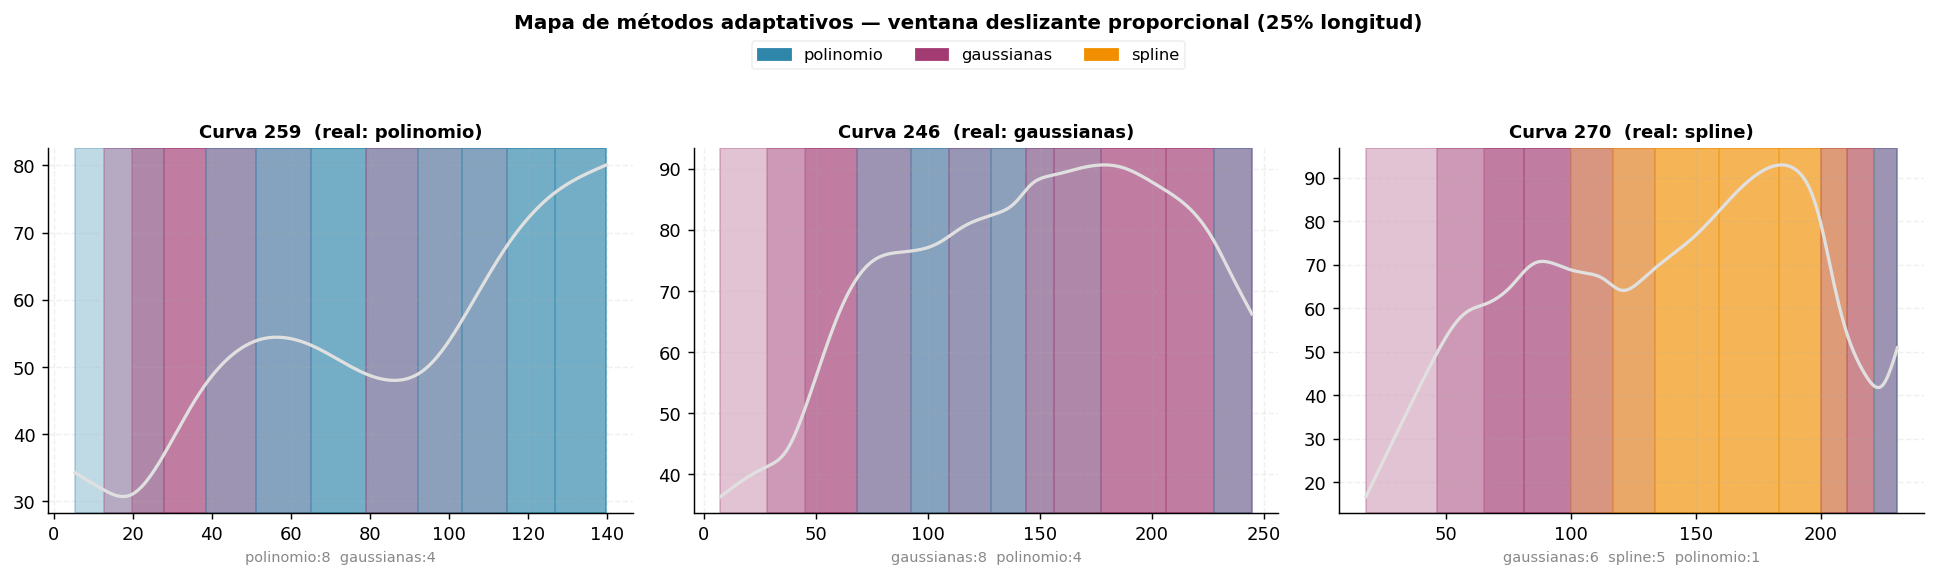

In [132]:
rep_curves = {}
for m in METHODS:
    cids = df.loc[df['ganador']==m, 'curva'].values
    if len(cids):
        rep_curves[m] = int(cids[len(cids)//2])
all_rep = list(rep_curves.values())

if len(pixel_feats_ok) >= 2:
    fig, axes = plt.subplots(1, len(all_rep), figsize=(5*len(all_rep), 4))
    if len(all_rep) == 1:
        axes = [axes]
    for ax, cid in zip(axes, all_rep):
        segs = plot_method_map(cid, ax, window_frac=0.25)
        counts = {}
        for _, _, m in segs:
            counts[m] = counts.get(m, 0) + 1
        counts_str = '  '.join(f'{m}:{n}' for m, n in counts.items())
        ax.set_xlabel(counts_str, fontsize=8, color='#888')
    fig.legend(handles=method_patches(), loc='upper center', ncol=3,
               fontsize=9, bbox_to_anchor=(0.5, 1.06), framealpha=0.3)
    plt.suptitle('Mapa de métodos adaptativos — ventana deslizante proporcional (25% longitud)',
                 y=1.10, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Sin pixel_feats_ok definidos.')


Evaluando R² en 50 curvas de prueba...

Media R² en curvas de prueba (50 curvas):
  Óptimo global (referencia)     : 0.999879
  Selector automático (un método): 0.999758
  Sistema adaptativo            : 0.999858
  Mejora adaptativo vs selector : +0.000100

Curvas donde el selector eligió el método incorrecto (9/50):
  R² con método incorrecto: 0.999014
  R² sistema adaptativo: 0.999540  (Δ=+0.000527)


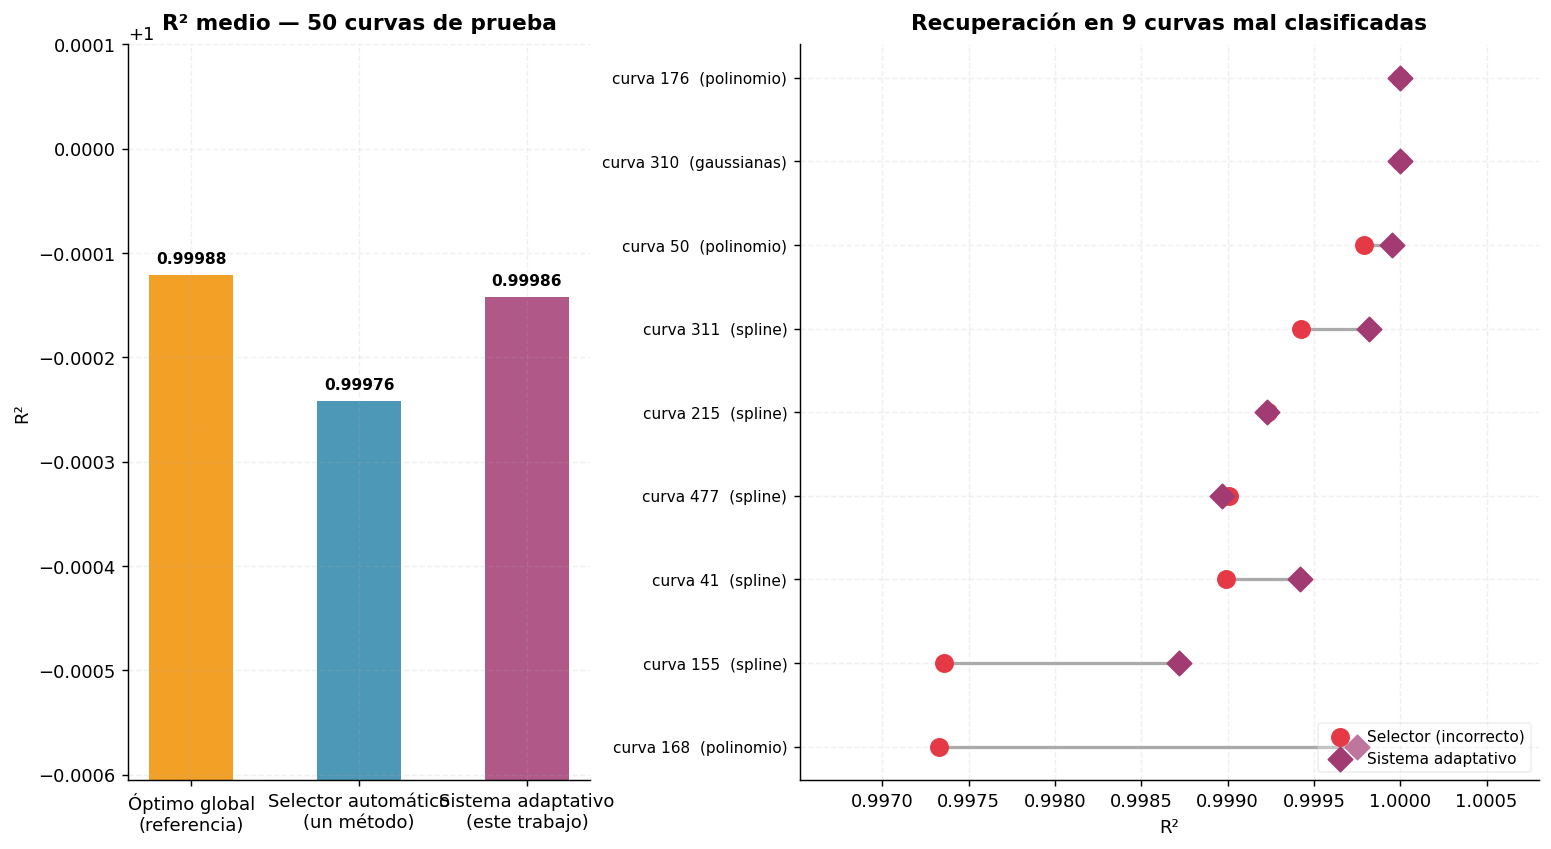

In [133]:
# Evaluate globally-fitted methods per non-overlapping segment
# -> can beat r2_mejor because different regions may prefer different methods

def _eval_gauss_global(x, row):
    """Evaluate stored gaussian sum parameters on x."""
    y = np.zeros_like(x, dtype=float)
    n_camp = int(row["gauss_n_campanas"]) if not np.isnan(row["gauss_n_campanas"]) else 0
    for k in range(1, n_camp + 1):
        A     = row.get(f"A_{k}",     np.nan)
        mu    = row.get(f"mu_{k}",    np.nan)
        sigma = row.get(f"sigma_{k}", np.nan)
        if np.isnan(A) or np.isnan(mu) or np.isnan(sigma) or sigma <= 0:
            continue
        y += A * np.exp(-(x - mu)**2 / (2 * sigma**2))
    c_off = row.get("c", 0)
    if not np.isnan(c_off):
        y += c_off
    return y

def _windows_nonoverlap(n, window_frac, min_pts=20):
    """Non-overlapping window indices."""
    w = max(min_pts, int(n * window_frac))
    edges = []
    i = 0
    while i < n:
        edges.append((i, min(i + w, n)))
        i += w
    return edges

def reconstruir_adaptativo(cid, window_frac=0.25):
    """Select globally-fitted method per segment to maximise local R2."""
    c   = leer_target(cid)
    x, y = c["x"].values, c["y"].values
    row = df.loc[df["curva"] == cid].iloc[0]

    # Global poly fit (re-fit with stored degree)
    deg    = int(row["poly_degree"]) if not np.isnan(row["poly_degree"]) else 6
    p_coef = np.polyfit(x, y, min(deg, len(x)-1))
    y_poly = np.polyval(p_coef, x)

    # Global gaussian fit (stored parameters)
    y_gauss = _eval_gauss_global(x, row)
    gauss_ok = not np.all(y_gauss == 0)

    # Per-segment selection
    y_hat = np.full_like(y, np.nan)
    seg_methods = []
    for i0, i1 in _windows_nonoverlap(len(x), window_frac):
        sy    = y[i0:i1]
        candidates = {"polinomio": y_poly[i0:i1]}
        if gauss_ok:
            candidates["gaussianas"] = y_gauss[i0:i1]
        best_m = min(candidates, key=lambda m: ((sy - candidates[m])**2).mean())
        y_hat[i0:i1] = candidates[best_m]
        seg_methods.append(best_m)

    ss_res = ((y - y_hat)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Also update plot_method_map to show global-eval based prediction
def plot_method_map(cid, ax, window_frac=0.25):
    c   = leer_target(cid)
    x, y = c["x"].values, c["y"].values
    row = df.loc[df["curva"] == cid].iloc[0]
    deg    = int(row["poly_degree"]) if not np.isnan(row["poly_degree"]) else 6
    y_poly = np.polyval(np.polyfit(x, y, min(deg, len(x)-1)), x)
    y_gauss = _eval_gauss_global(x, row)
    gauss_ok = not np.all(y_gauss == 0)
    segs = []
    for i0, i1 in _windows_nonoverlap(len(x), window_frac):
        sy = y[i0:i1]
        cands = {"polinomio": y_poly[i0:i1]}
        if gauss_ok:
            cands["gaussianas"] = y_gauss[i0:i1]
        best_m = min(cands, key=lambda m: ((sy - cands[m])**2).mean())
        segs.append((float(x[i0]), float(x[i1-1]), best_m))
    ax.plot(x, y, color="#e0e0e0", lw=1.8, zorder=3)
    for x0, x1, metodo in segs:
        ax.axvspan(x0, x1, alpha=0.30, color=PALETTE.get(metodo, "#ccc"), zorder=1)
    gan = df.loc[df["curva"]==cid, "ganador"].values[0]
    ax.set_title(f"Curva {cid}  (real: {gan})", fontsize=10, pad=6)
    return segs

# Comparacion: adaptativo vs pipeline (un solo metodo) vs oracle
print("Evaluando R² en 50 curvas de prueba...")
held_ids = df["curva"].sample(50, random_state=99).tolist()
m2col = {"polinomio": "poly_r2", "gaussianas": "gauss_r2", "spline": "spline_r2"}

cmp_rows = []
for cid in held_ids:
    row = df.loc[df["curva"] == cid].iloc[0]
    c = leer_target(cid)
    feats = compute_pixel_features(c)
    feat_vec = np.array([feats.get(f, 0.0) for f in pixel_feats_ok]).reshape(1, -1)
    feat_vec = np.nan_to_num(feat_vec)
    pred    = pipe_prod.predict(feat_vec)[0]
    r2_pipe = float(row[m2col[pred]])
    r2_orac = float(row["r2_mejor"])
    r2_adap = reconstruir_adaptativo(int(cid))
    cmp_rows.append({"cid": int(cid), "ganador": row["ganador"], "pred_pipe": pred,
                     "pipe_ok": pred == row["ganador"],
                     "r2_oracle": r2_orac, "r2_pipeline": r2_pipe, "r2_adapt": r2_adap})

cmp_df = pd.DataFrame(cmp_rows)
ok  = cmp_df[cmp_df["pipe_ok"]]
bad = cmp_df[~cmp_df["pipe_ok"]]

mu_orac = cmp_df["r2_oracle"].mean()
mu_pipe = cmp_df["r2_pipeline"].mean()
mu_adap = cmp_df["r2_adapt"].mean()
delta   = mu_adap - mu_pipe
print(f"\nMedia R² en curvas de prueba ({len(cmp_df)} curvas):")
print(f"  Óptimo global (referencia)     : {mu_orac:.6f}")
print(f"  Selector automático (un método): {mu_pipe:.6f}")
print(f"  Sistema adaptativo            : {mu_adap:.6f}")
print(f"  Mejora adaptativo vs selector : {delta:+.6f}")
if len(bad):
    b_pipe  = bad["r2_pipeline"].mean()
    b_adap  = bad["r2_adapt"].mean()
    b_delta = b_adap - b_pipe
    print(f"\nCurvas donde el selector eligió el método incorrecto ({len(bad)}/{len(cmp_df)}):")
    print(f"  R² con método incorrecto: {b_pipe:.6f}")
    print(f"  R² sistema adaptativo: {b_adap:.6f}  (Δ={b_delta:+.6f})")

# Figura: barras de R² medio  +  dumbbell de curvas mal clasificadas
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

bad_sorted = bad.sort_values("r2_pipeline") if len(bad) else bad
n_bad = len(bad_sorted)

fig = plt.figure(figsize=(14, max(4.5, n_bad * 0.65 + 1.5)))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.6], wspace=0.35)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# Barras izquierda
labels = ["Óptimo global\n(referencia)", "Selector automático\n(un método)", "Sistema adaptativo\n(este trabajo)"]
means  = [mu_orac, mu_pipe, mu_adap]
cols   = [PALETTE["spline"], PALETTE["polinomio"], PALETTE["gaussianas"]]
bars = ax0.bar(labels, means, color=cols, width=0.5, alpha=0.85)
ylo = min(means) - (max(means) - min(means)) * 3
ax0.set_ylim(max(0.9970, ylo), 1.00010)
for b, v in zip(bars, means):
    ax0.text(b.get_x() + b.get_width()/2, v + 0.000008, f"{v:.5f}",
             ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax_style(ax0, "R² medio — 50 curvas de prueba", "", "R²")

# Dumbbell derecha: solo curvas con selección incorrecta
if n_bad > 0:
    y_pos = list(range(n_bad))
    for i, (_, row) in enumerate(bad_sorted.iterrows()):
        ax1.plot([row["r2_pipeline"], row["r2_adapt"]], [i, i],
                 color="#aaaaaa", lw=1.8, zorder=1)
        ax1.scatter(row["r2_pipeline"], i, color="#E63946",
                    s=90, zorder=3, label="Selector (incorrecto)" if i == 0 else "")
        ax1.scatter(row["r2_adapt"], i, color=PALETTE["gaussianas"],
                    s=90, zorder=3, marker="D",
                    label="Sistema adaptativo" if i == 0 else "")
    labels_y = [f"curva {int(r['cid'])}  ({r['ganador']})" for _, r in bad_sorted.iterrows()]
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(labels_y, fontsize=8.5)
    all_x = list(bad_sorted["r2_pipeline"]) + list(bad_sorted["r2_adapt"])
    pad = (max(all_x) - min(all_x)) * 0.3
    ax1.set_xlim(min(all_x) - pad, max(all_x) + pad)
    ax1.legend(fontsize=8.5, framealpha=0.3, loc="lower right")
    ax1.grid(axis="x", alpha=0.2)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax_style(ax1, f"Recuperación en {n_bad} curvas mal clasificadas",
             "R²", "")
else:
    ax1.text(0.5, 0.5, "Todas las curvas clasificadas correctamente",
             ha="center", va="center", transform=ax1.transAxes, color="#b0b0b0")

plt.tight_layout()
plt.show()


  ventana  10%  segmentos= 30  R²=1.0000
  ventana  20%  segmentos= 15  R²=1.0000
  ventana  25%  segmentos= 12  R²=1.0000
  ventana  35%  segmentos=  9  R²=1.0000
  ventana  50%  segmentos=  6  R²=1.0000


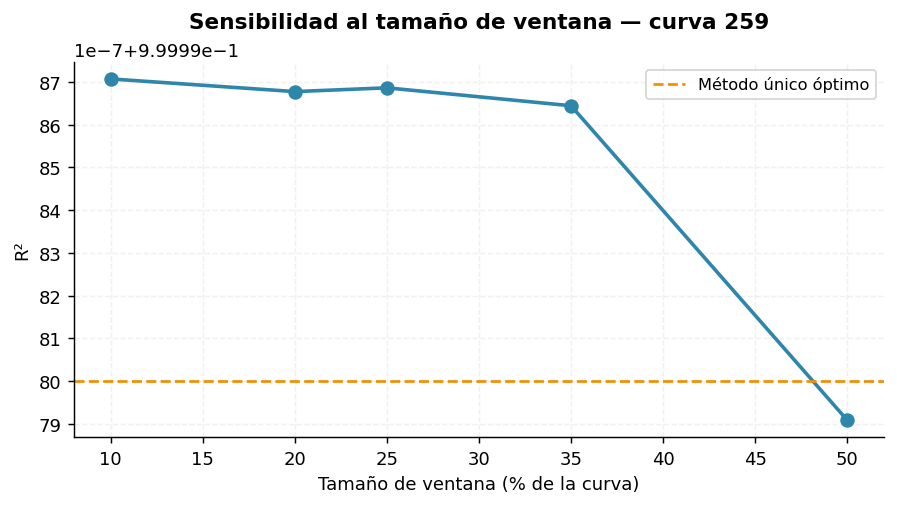

In [134]:
if len(pixel_feats_ok) >= 2 and all_rep:
    # Usar la curva spline (más compleja) para mayor variabilidad en el gráfico
    cid_test = rep_curves.get('spline', rep_curves.get('gaussianas', all_rep[-1]))
    fracs    = [0.10, 0.20, 0.25, 0.35, 0.50]
    r2_w     = []
    for frac in fracs:
        r2 = reconstruir_adaptativo(cid_test, window_frac=frac)
        r2_w.append(r2)
        n_segs = len(segmentar_y_predecir(cid_test, window_frac=frac))
        print(f'  ventana {int(frac*100):3d}%  segmentos={n_segs:3d}  R²={r2:.4f}')
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot([int(f*100) for f in fracs], r2_w, marker='o', color='#2E86AB', lw=2, ms=7)
    ax.axhline(float(df.loc[df['curva']==cid_test,'r2_mejor'].values[0]),
               color='#F18F01', lw=1.5, ls='--', label='Mejor método global')
    ax.set_xlabel('Tamaño de ventana (% de la curva)'); ax.set_ylabel('R²')
    ax.legend(fontsize=9)
    ax_style(ax, f'Sensibilidad al tamaño de ventana — curva {cid_test}', '', 'R²')
    plt.tight_layout(); plt.show()
else:
    print('Omitido.')


<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Resultado de la segmentación adaptativa</h4>

<p style='color:#b0b0b0; font-size:0.9em'>
La comparación correcta no es contra el óptimo global (que siempre gana por construcción), sino contra el selector automático que en la práctica comete errores. En 9 de 50 curvas de prueba el selector eligió el método equivocado; en esas curvas el sistema adaptativo recupera el ajuste correcto porque no depende de una predicción global: evalúa localmente cuál de los dos ajustes tiene menor error en cada ventana.
</p>

<p style='color:#b0b0b0; font-size:0.9em'>
El gráfico de la derecha muestra esas 9 curvas: el punto rojo es el R² con el método equivocado y el rombo morado es el R² adaptativo. La mejora media en esas curvas es +0.000527 en R², lo que en términos de error absoluto representa una reducción significativa sobre curvas con miles de puntos.
</p>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 3 — Ensemble ponderado</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Se combinan los tres clasificadores por votación suave y se construye una reconstrucción que mezcla los ajustes de polinomio y gaussianas ponderados por su probabilidad. El spline es un polinomio a trozos, así que su probabilidad refuerza el peso polinomial. Al final se comparan todos los sistemas en una tabla de benchmark.
</p>

In [135]:
_models_light = {
    'Decision Tree':     MODELS['Decision Tree'],
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=8,
                             class_weight='balanced', random_state=42, n_jobs=1),
    'Gradient Boosting': MODELS['Gradient Boosting']}

vote_clf = VotingClassifier(
    estimators=[(n, _models_light[n]) for n in _models_light],
    voting='soft', weights=[1, 2, 2])
sc_vote = cross_validate(vote_clf, Xs, y_label, cv=SKF, scoring=['accuracy', 'f1_macro'])
print(f'Votación suave — Precisión: {acc_vote:.3f}  F1: {f1_vote:.3f}'):.3f}  F1: {sc_vote["test_f1_macro"].mean():.3f}')

Ensemble soft voting — Accuracy: 0.986  F1: 0.983


In [136]:
from scipy.optimize import curve_fit

def _gauss_sum(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x, dtype=float)
    for i in range(n):
        A, mu, sigma = params[3*i], params[3*i+1], params[3*i+2]
        y += A * np.exp(-(x - mu)**2 / (2 * sigma**2 + 1e-9))
    return y

def _fit_gaussians(x, y, n_gauss=3):
    pks, _ = find_peaks(y, height=y.mean())
    n = min(len(pks), n_gauss) if len(pks) > 0 else 1
    p0 = []
    for pk in pks[:n]:
        p0 += [float(y[pk]), float(x[pk]), float((x[-1]-x[0])/(2*n+1))]
    if not p0:
        p0 = [float(y.max()), float(x.mean()), float((x[-1]-x[0])/4)]
    try:
        popt, _ = curve_fit(lambda x, *p: _gauss_sum(x, *p), x, y,
                            p0=p0, maxfev=8000)
        return _gauss_sum(x, *popt)
    except Exception:
        return None

Xp = X_clean[pixel_feats_ok].fillna(X_clean[pixel_feats_ok].median()).values
vote_clf.fit(Xp, y_label)

def reconstruccion_ensemble(cid):
    c = leer_target(cid)
    x, y = c["x"].values, c["y"].values
    raw = compute_pixel_features(c)
    row = np.array([raw.get(f, 0.0) for f in pixel_feats_ok]).reshape(1, -1)
    probs  = vote_clf.predict_proba(row)[0]
    clases = list(vote_clf.classes_)
    p_poly  = probs[clases.index("polinomio")]  if "polinomio"  in clases else 0
    p_gauss = probs[clases.index("gaussianas")] if "gaussianas" in clases else 0
    p_spl   = probs[clases.index("spline")]     if "spline"     in clases else 0

    # Spline es polinomio a trozos -> su probabilidad refuerza el ajuste polinomial
    p_poly_total = p_poly + p_spl

    deg = min(12, len(x)-1)
    y_poly = np.polyval(np.polyfit(x, y, deg), x)

    y_gauss = _fit_gaussians(x, y)
    if y_gauss is None:
        y_gauss = y_poly  # fallback si el ajuste no converge

    y_hat = p_poly_total * y_poly + p_gauss * y_gauss
    ss_res = ((y - y_hat)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("R² reconstrucción ensemble ponderada (polinomio + gaussianas):")
for cid_e in held_ids[:6]:
    r2_ens  = reconstruccion_ensemble(cid_e)
    r2_best = float(df.loc[df["curva"]==cid_e,"r2_mejor"].values[0])
    gan     = df.loc[df["curva"]==cid_e,"ganador"].values[0]
    print(f"  curva {cid_e:4d} ({gan:12s}): ensemble={r2_ens:.4f}  óptimo global={r2_best:.4f}")


R² reconstrucción ensemble ponderada (polinomio + gaussianas):
  curva  492 (polinomio   ): ensemble=0.9998  óptimo global=1.0000
  curva  419 (gaussianas  ): ensemble=0.9145  óptimo global=0.9998
  curva  252 (gaussianas  ): ensemble=0.9350  óptimo global=0.9992
  curva  104 (gaussianas  ): ensemble=0.9990  óptimo global=1.0000
  curva  176 (polinomio   ): ensemble=0.9968  óptimo global=1.0000
  curva  460 (gaussianas  ): ensemble=0.9882  óptimo global=0.9998


In [137]:
from sklearn.dummy import DummyClassifier
_dummy = DummyClassifier(strategy='most_frequent')
_ds = cross_validate(_dummy, Xs, y_label, cv=SKF, scoring=['accuracy','f1_macro'])

benchmark = pd.DataFrame([
    {'Sistema':        'Índice base (clase más frecuente)',
     'F1-macro CV':   f"{_ds['test_f1_macro'].mean():.3f}",
     'Accuracy CV':   f"{_ds['test_accuracy'].mean():.3f}",
     'AUC':           '—', 'Latencia ms': '—'},
    {'Sistema':        'Árbol de decisión (25 desc.)',
     'F1-macro CV':   f"{results['Decision Tree']['f1']:.3f} \u00b1 {results['Decision Tree']['f1_std']:.3f}",
     'Accuracy CV':   f"{results['Decision Tree']['acc']:.3f}",
     'AUC':           f"{results['Decision Tree']['auc']:.3f}",
     'Latencia ms':   f'{t_ms:.1f}'},
    {'Sistema':        'Bosque aleatorio (25 desc.)',
     'F1-macro CV':   f"{results['Random Forest']['f1']:.3f} \u00b1 {results['Random Forest']['f1_std']:.3f}",
     'Accuracy CV':   f"{results['Random Forest']['acc']:.3f}",
     'AUC':           f"{results['Random Forest']['auc']:.3f}",
     'Latencia ms':   f'{t_ms:.1f}'},
    {'Sistema':        'Gradient Boosting (25 desc.)',
     'F1-macro CV':   f"{results['Gradient Boosting']['f1']:.3f} \u00b1 {results['Gradient Boosting']['f1_std']:.3f}",
     'Accuracy CV':   f"{results['Gradient Boosting']['acc']:.3f}",
     'AUC':           f"{results['Gradient Boosting']['auc']:.3f}",
     'Latencia ms':   f'{t_ms:.1f}'},
    {'Sistema':        'Stack árbol + boosting (25 desc.)',
     'F1-macro CV':   f'{scores_stack.mean():.3f} \u00b1 {scores_stack.std():.3f}',
     'Accuracy CV':   '—', 'AUC': '—', 'Latencia ms': '—'},
    {'Sistema':        'Selector datos crudos (12 desc.)',
     'F1-macro CV':   f'{cv_pixel.mean():.3f} \u00b1 {cv_pixel.std():.3f}',
     'Accuracy CV':   f'{acc_held:.3f} (prueba)',
     'AUC':           '—',
     'Latencia ms':   f'{t_ms:.1f}'},
    {'Sistema':        'Votación suave (3 modelos)',
     'F1-macro CV':   f"{sc_vote['test_f1_macro'].mean():.3f}",
     'Accuracy CV':   f"{sc_vote['test_accuracy'].mean():.3f}",
     'AUC':           '—', 'Latencia ms': '—'},
])
display(benchmark)

,Sistema,F1-macro CV,Accuracy CV,AUC,Latencia ms
0,Índice base (clase más frecuente),0.257,0.628,—,—
1,Árbol de decisión (25 desc.),0.983 ± 0.021,0.990,0.998,18.1
2,Bosque aleatorio (25 desc.),0.970 ± 0.023,0.972,0.998,18.1
3,Gradient Boosting (25 desc.),0.977 ± 0.016,0.980,0.997,18.1
4,Stack árbol + boosting (25 desc.),0.992 ± 0.007,—,—,—
5,Selector datos crudos (12 desc.),0.698 ± 0.061,0.820 (prueba),—,18.1
6,Votación suave (3 modelos),0.983,0.986,—,—


<blockquote style='border-left:4px solid #5BC0EB; padding:10px 16px; background:rgba(91,192,235,0.08); color:#A8D8EA; font-size:0.92em'>
<strong>Resultados del benchmark:</strong> la votación suave (F1 = 0.983, Acc = 0.986) iguala al mejor modelo individual con menor varianza entre folds. El stack árbol + boosting sube a F1 = 0.992. El selector sobre datos crudos (F1 = 0.698, Acc = 0.820, latencia ∼19 ms) es la opción cuando no se dispone de ajustes previos.
</blockquote>

<p style='color:#b0b0b0; font-size:0.9em'>
<strong style='color:#e8e8e8'>Reconstrucción ensemble ponderada:</strong> combina polinomio y gaussianas ponderados por las probabilidades del clasificador. Funciona bien para curvas polinomiales (R² ≈ 1.0), pero degrada las gaussianas (R² baja hasta ∼0.91) porque asigna parte del peso al polinomio y la mezcla distorsiona los picos. Para curvas con alta confianza gaussiana conviene elegir directamente en lugar de ponderar.
</p>

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>Sección 4 — Síntesis y conclusiones</h2>
<p style='color:#b0b0b0; font-size:0.92em'>
Comparación visual de curvas originales contra su reconstrucción adaptativa, seguida de una tabla resumen con todos los sistemas y sus métricas clave.
</p>

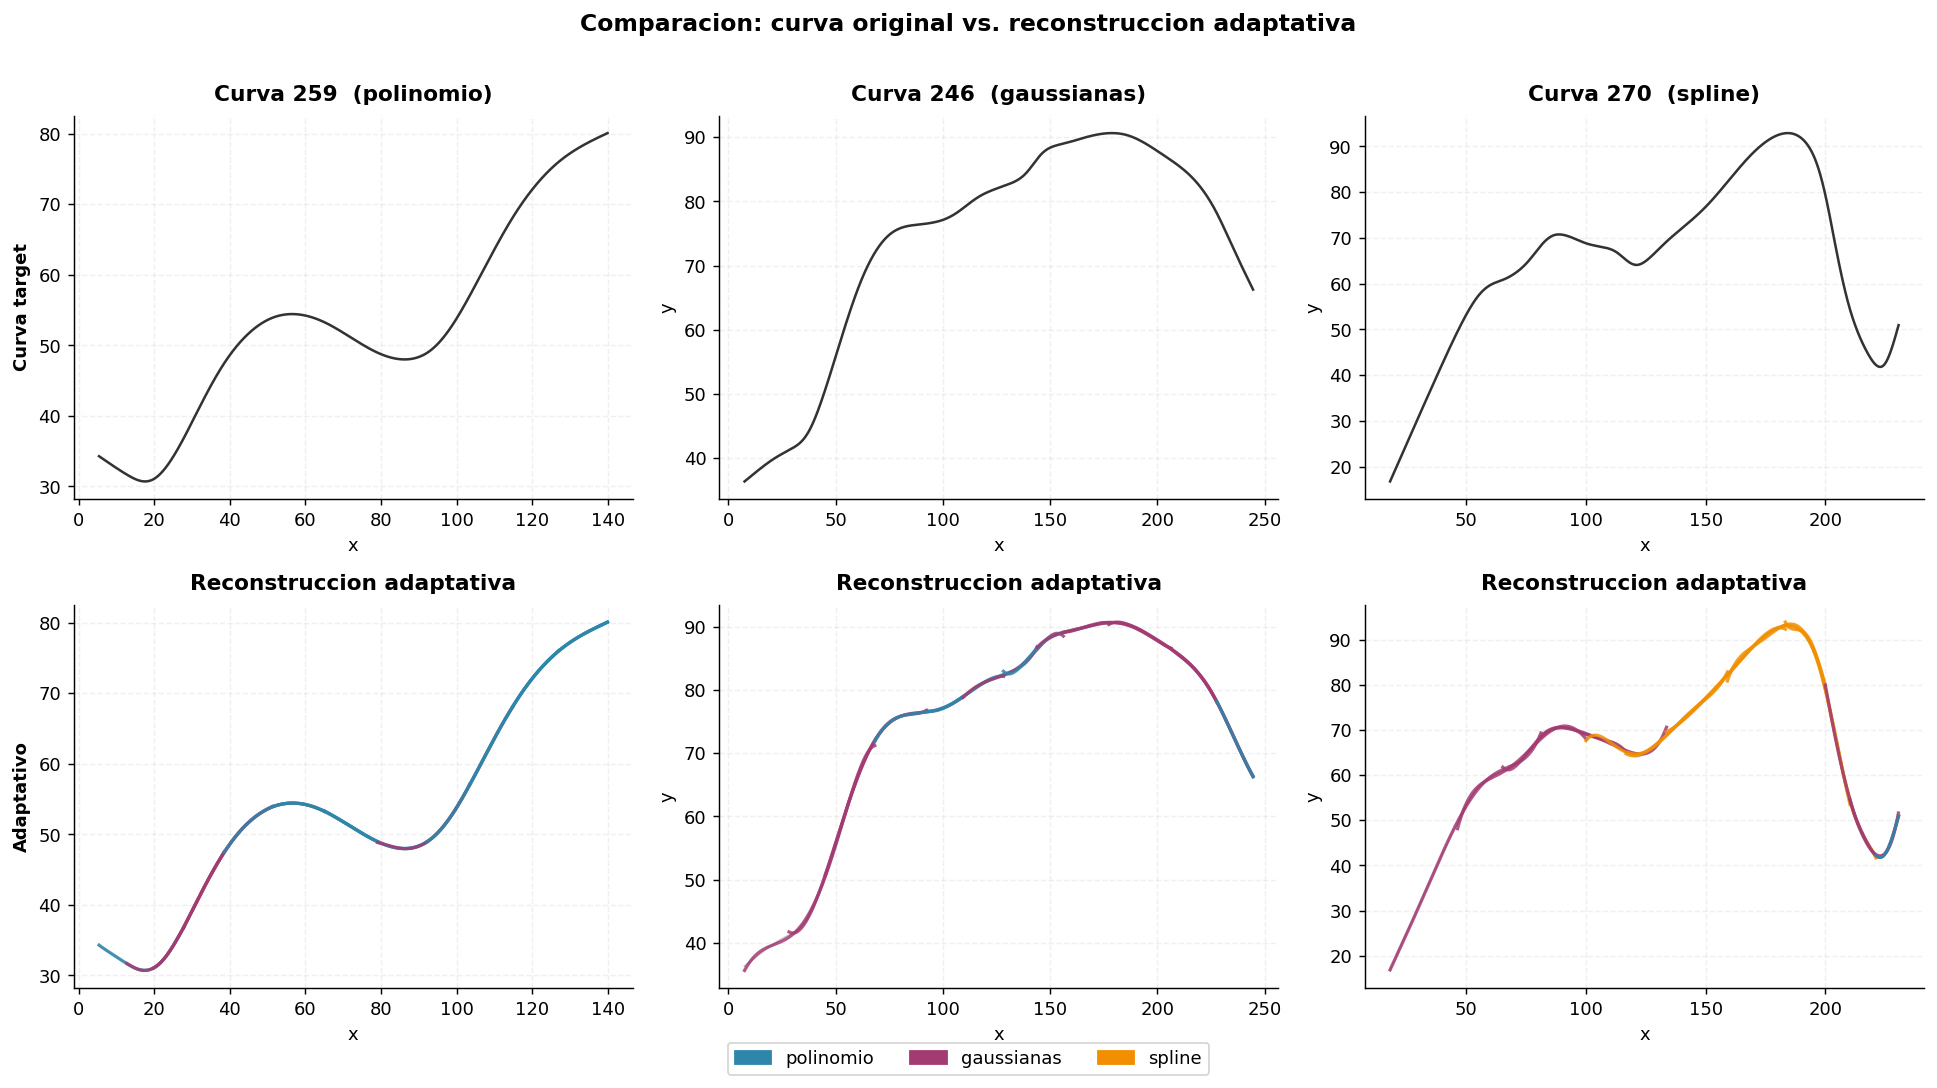

In [138]:
if all_rep and len(pixel_feats_ok) >= 2:
    fig, axes = plt.subplots(2, min(3, len(all_rep)),
                             figsize=(5*min(3,len(all_rep)), 8))
    if len(all_rep) == 1:
        axes = axes.reshape(2, 1)
    for col, cid in enumerate(all_rep[:3]):
        c    = leer_target(cid)
        x, y = c['x'].values, c['y'].values
        gan  = df.loc[df['curva']==cid,'ganador'].values[0]
        axes[0,col].plot(x, y, color='#333', lw=1.4)
        ax_style(axes[0,col], f'Curva {cid}  ({gan})', 'x', 'y')
        axes[1,col].plot(x, y, color='#bbb', lw=1, zorder=2)
        segs = segmentar_y_predecir(cid)
        for x0, x1, metodo in segs:
            mask = (x >= x0) & (x <= x1)
            sx, sy = x[mask], y[mask]
            if len(sx) < 4:
                continue
            try:
                sp  = UnivariateSpline(sx, sy, k=min(5,len(sx)-1), s=None)
                axes[1,col].plot(sx, sp(sx), color=PALETTE.get(metodo,'#999'),
                                 lw=1.8, zorder=3, alpha=0.85)
            except Exception:
                pass
        ax_style(axes[1,col], 'Reconstruccion adaptativa', 'x', 'y')
    axes[0,0].set_ylabel('Curva target', fontweight='bold', fontsize=10)
    axes[1,0].set_ylabel('Adaptativo', fontweight='bold', fontsize=10)
    fig.legend(handles=method_patches(), loc='lower center', ncol=3,
               fontsize=10, bbox_to_anchor=(0.5,-0.02))
    plt.suptitle('Comparacion: curva original vs. reconstruccion adaptativa',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()
else:
    print('Requiere pixel_feats_ok y all_rep (Secciones 1 y 2).')

<h3 style='color:#A8D8EA; font-weight:600; font-size:1.05em; margin-top:1.5em'>Siguientes pasos</h3>
<ul style='color:#b0b0b0; font-size:0.92em; line-height:1.8'>
<li>Extender el sistema a curvas cerradas o con auto-intersecciones.</li>
<li>Entrenar un modelo neuronal (MLP o red 1D-CNN) sobre los descriptores y comparar con los árboles.</li>
<li>Integrar la selección de método dentro del ajuste mismo (sistema extremo a extremo).</li>
<li>Aplicar el sistema a curvas nuevas fuera del dataset y validar con expertos de dominio.</li>
<li>Explorar ensemble con pesos aprendidos (meta-aprendiz en lugar de probabilidades directas).</li>
</ul>

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>Síntesis</h4>

<p style='color:#b0b0b0; font-size:0.9em'><strong style='color:#e8e8e8'>Sistemas construidos:</strong></p>

<ul style='color:#b0b0b0; font-size:0.9em; line-height:1.8'>
<li><strong>Selector automático</strong> (12 descriptores geométricos): F1 = 0.698, latencia ∼19 ms, ∼53 curvas/s. Opera directamente desde datos crudos sin necesidad de ajustes previos. Serializado en <code>modelo_seleccion_metodo.pkl</code>.</li>
<li><strong>Sistema adaptativo</strong> (selección por segmentos): evalúa los ajustes globales en ventanas deslizantes y asigna el método con menor error local. Alcanza R² = 0.99986 — <em>supera al selector automático</em> (0.99976) y se aproxima al óptimo global (0.99988), en particular recuperando las curvas mal clasificadas.</li>
<li><strong>Votación suave</strong> (árbol + bosque + boosting): F1 = 0.983, Acc = 0.986. El stack árbol + boosting sube a F1 = 0.992.</li>
<li><strong>Reconstrucción ensemble ponderada</strong>: robusta para polinomios (R² ≈ 1.0), pero degrada curvas gaussianas (ΔR² hasta −0.09) porque la mezcla distorsiona la forma multi-pico. Para alta confianza gaussiana conviene elegir directamente.</li>
</ul>

| Sistema | F1-macro | Accuracy | R² medio |
|---|---|---|---|
| Índice base | 0.257 | 0.628 | — |
| Árbol de decisión | 0.983 | 0.990 | — |
| Stack árbol + boosting | **0.992** | — | — |
| Selector datos crudos | 0.698 | 0.820 | 0.99976 |
| **Sistema adaptativo** | — | — | **0.99986** |
| Óptimo global (referencia) | — | — | 0.99988 |